# NumPy MLP Trial Comparison

## Goal

Collect the validation-only trial outputs, rank candidate hyperparameters, and write the selected configuration for the final held-out test evaluation notebook.

## Compare Validation Trials

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
{'run_mode': 'final', 'output_root': '/content/drive/MyDrive/Colab Notebooks/Education/ProgMathsAI/task1_outputs', 'comparison_dir': '/content/drive/MyDrive/Colab Notebooks/Education/ProgMathsAI/task1_outputs/numpy_mlp_trials/06_trial_comparison'}


,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,trial,trial_factor,variant,epochs_trained,parameter_count,...,activation,dropout,l1,l2,optimizer,learning_rate,decay,batch_size,configured_epochs,source_file
0,0.727551,0.727551,0.727197,0.727551,0.727080,03_dropout_regularisation_trial,Dropout and weight regularisation,dropout_0p2_l2_1e_minus_4,37,18949,...,relu,0.2,0.0,0.0001,momentum,0.010,0.01,64,50,/content/drive/MyDrive/Colab Notebooks/Educati...
1,0.726531,0.726531,0.726992,0.726531,0.726427,05_learningrate_batchsize_trial,"Learning rate, decay, and batch size",lr_0p01_decay_0p02,37,18949,...,relu,0.2,0.0,0.0000,momentum,0.010,0.02,64,50,/content/drive/MyDrive/Colab Notebooks/Educati...
2,0.725510,0.725510,0.722884,0.725510,0.723543,05_learningrate_batchsize_trial,"Learning rate, decay, and batch size",lr_0p006_batch_64,48,18949,...,relu,0.2,0.0,0.0000,momentum,0.006,0.01,64,50,/content/drive/MyDrive/Colab Notebooks/Educati...
3,0.722449,0.722449,0.721033,0.722449,0.721557,05_learningrate_batchsize_trial,"Learning rate, decay, and batch size",lr_0p01_batch_128,50,18949,...,relu,0.2,0.0,0.0000,momentum,0.010,0.01,128,50,/content/drive/MyDrive/Colab Notebooks/Educati...
4,0.722449,0.722449,0.718359,0.722449,0.719511,04_architecture_trial,Hidden-layer architecture,two_layer_256_128,22,54277,...,relu,0.2,0.0,0.0000,momentum,0.010,0.01,64,50,/content/drive/MyDrive/Colab Notebooks/Educati...
5,0.717347,0.717347,0.717771,0.717347,0.717482,00_baseline,Baseline reference,baseline_relu_momentum,35,18949,...,relu,0.2,0.0,0.0000,momentum,0.010,0.01,64,50,/content/drive/MyDrive/Colab Notebooks/Educati...
6,0.717347,0.717347,0.717771,0.717347,0.717482,01_activation_trial,Hidden activation function,relu_activation,35,18949,...,relu,0.2,0.0,0.0000,momentum,0.010,0.01,64,50,/content/drive/MyDrive/Colab Notebooks/Educati...
7,0.717347,0.717347,0.717771,0.717347,0.717482,02_optimizer_trial,Optimizer,momentum_optimizer,35,18949,...,relu,0.2,0.0,0.0000,momentum,0.010,0.01,64,50,/content/drive/MyDrive/Colab Notebooks/Educati...
8,0.717347,0.717347,0.717771,0.717347,0.717482,03_dropout_regularisation_trial,Dropout and weight regularisation,dropout_0p2,35,18949,...,relu,0.2,0.0,0.0000,momentum,0.010,0.01,64,50,/content/drive/MyDrive/Colab Notebooks/Educati...
9,0.717347,0.717347,0.717771,0.717347,0.717482,04_architecture_trial,Hidden-layer architecture,two_layer_128_64,35,18949,...,relu,0.2,0.0,0.0000,momentum,0.010,0.01,64,50,/content/drive/MyDrive/Colab Notebooks/Educati...


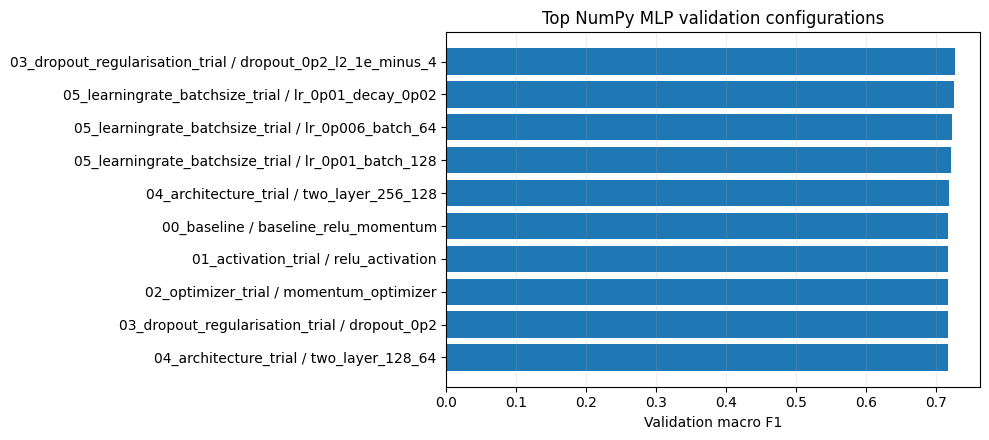

Saved selected hyperparameters to /content/drive/MyDrive/Colab Notebooks/Education/ProgMathsAI/task1_outputs/numpy_mlp_trials/selected/selected_hyperparameters_final.json


In [1]:
import importlib.util
import subprocess
import sys

import copy
import hashlib
import json
import math
import os
import random
import time
import warnings
import zipfile
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.io import wavfile
from scipy.signal import resample_poly

IN_COLAB = (
    importlib.util.find_spec("google") is not None
    and importlib.util.find_spec("google.colab") is not None
)
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    default_root = Path("/content/drive/MyDrive/Colab Notebooks/Education/ProgMathsAI")
else:
    default_root = Path.cwd()
    if not (default_root / "Fake Music Caps.zip").exists() and (default_root.parent / "Fake Music Caps.zip").exists():
        default_root = default_root.parent

# Purpose: Uses the real project folder as the root for datasets and saved outputs.
# In Colab, this should point to the mounted Google Drive project folder.
# Outside Colab, it falls back to the current local project folder.

os.environ.setdefault("PROGMATHSAI_PROJECT_ROOT", str(default_root))

PROJECT_ROOT = Path(os.environ["PROGMATHSAI_PROJECT_ROOT"]).expanduser().resolve()
OUTPUT_ROOT = Path(
    os.environ.get("FAKEMUSICCAPS_OUTPUT_ROOT", str(PROJECT_ROOT / "task1_outputs"))
).expanduser().resolve()

RUN_MODE = "final"
# Final submission mode is fixed intentionally.
# These notebooks always use the full configured split, full epoch/patience settings,
# and _final output files.

MODEL_TAG = "numpy_mlp_trials"
TRIAL_TAG = "06_trial_comparison"
OUTPUT_DIR = OUTPUT_ROOT / MODEL_TAG / TRIAL_TAG
FIGURES_DIR = OUTPUT_DIR / "figures"
METRICS_DIR = OUTPUT_DIR / "metrics"
TABLES_DIR = OUTPUT_DIR / "tables"
SELECTED_DIR = OUTPUT_ROOT / MODEL_TAG / "selected"
for directory in (FIGURES_DIR, METRICS_DIR, TABLES_DIR, SELECTED_DIR):
    directory.mkdir(parents=True, exist_ok=True)

TRIAL_TAGS = [
    "00_baseline",
    "01_activation_trial",
    "02_optimizer_trial",
    "03_dropout_regularisation_trial",
    "04_architecture_trial",
    "05_learningrate_batchsize_trial",
]

print({
    "run_mode": RUN_MODE,
    "output_root": str(OUTPUT_ROOT),
    "comparison_dir": str(OUTPUT_DIR),
})


def to_jsonable(value):
    if isinstance(value, dict):
        return {key: to_jsonable(item) for key, item in value.items()}
    if isinstance(value, list):
        return [to_jsonable(item) for item in value]
    if hasattr(value, "item"):
        return value.item()
    return value


frames = []
missing = []
for tag in TRIAL_TAGS:
    path = OUTPUT_ROOT / MODEL_TAG / tag / "tables" / f"validation_{tag}_{RUN_MODE}.csv"
    if path.exists():
        frame = pd.read_csv(path)
        frame["source_file"] = str(path)
        frames.append(frame)
    else:
        missing.append(str(path))

if missing:
    print("Missing validation tables:")
    for path in missing:
        print(f"- {path}")
if not frames:
    raise FileNotFoundError(
        "No validation tables were found. Run the validation trial notebooks before comparison."
    )

combined = pd.concat(frames, ignore_index=True).sort_values(
    ["macro_f1", "balanced_accuracy", "accuracy"], ascending=False
).reset_index(drop=True)
comparison_path = TABLES_DIR / f"trial_comparison_{RUN_MODE}.csv"
combined.to_csv(comparison_path, index=False)
display(combined.head(20))

top = combined.head(min(10, len(combined))).copy()
top["label"] = top["trial"].astype(str) + " / " + top["variant"].astype(str)
fig, ax = plt.subplots(figsize=(10, max(4, 0.45 * len(top))))
ax.barh(top["label"][::-1], top["macro_f1"][::-1])
ax.set_xlabel("Validation macro F1")
ax.set_title("Top NumPy MLP validation configurations")
ax.grid(axis="x", alpha=0.2)
fig.tight_layout()
figure_path = FIGURES_DIR / f"validation_macro_f1_top_configs_{RUN_MODE}.png"
fig.savefig(figure_path, dpi=160)
plt.show()

best = combined.iloc[0]
selected_config = {
    "name": str(best["variant"]),
    "hidden_sizes": json.loads(str(best["hidden_sizes_json"])),
    "activation": str(best["activation"]),
    "dropout": float(best.get("dropout", 0.0)),
    "l1": float(best.get("l1", 0.0)),
    "l2": float(best.get("l2", 0.0)),
    "optimizer": str(best["optimizer"]),
    "learning_rate": float(best["learning_rate"]),
    "decay": float(best.get("decay", 0.0)),
    "batch_size": int(best.get("batch_size", 64)),
    "epochs": int(best.get("configured_epochs", 50)),
}
selected_payload = {
    "model": "NumPy MLP",
    "run_mode": RUN_MODE,
    "selection_metric": "validation_macro_f1_then_balanced_accuracy_then_accuracy",
    "selected_trial": str(best["trial"]),
    "selected_variant": str(best["variant"]),
    "selected_config": selected_config,
    "selected_validation_row": best.to_dict(),
    "comparison_table": str(comparison_path),
    "top_configs_figure": str(figure_path),
}
selected_path = SELECTED_DIR / f"selected_hyperparameters_{RUN_MODE}.json"
selected_path.write_text(json.dumps(to_jsonable(selected_payload), indent=2), encoding="utf-8")
print(f"Saved selected hyperparameters to {selected_path}")
